In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data=pd.read_csv('day-wise-state-wise-air-quality-index-aqi-of-major-cities-and-towns-in-india.csv')

---
4. Which months consistently show the worst air quality across Indian states — 
(Consider top 10 states with high distinct areas) 
---

In [12]:
data['date']=pd.to_datetime(data['date'],format='%d-%m-%Y')
area_count=data.groupby('state')['area'].nunique().sort_values(ascending=False).head(10).reset_index()
area_count=pd.DataFrame(area_count)
top_10_states=list(area_count['state'])
df=data[data['state'].isin(top_10_states)].copy()
df['month_name']=df['date'].dt.month_name()
result=df.groupby(['state','month_name'])['aqi_value'].mean().reset_index(name='avg_monthly_aqi')
result

,state,month_name,avg_monthly_aqi
0,Andhra Pradesh,April,69.884236
1,Andhra Pradesh,August,56.611448
2,Andhra Pradesh,December,116.136882
3,Andhra Pradesh,February,98.842563
4,Andhra Pradesh,January,123.793103
...,...,...,...
115,Uttar Pradesh,March,147.201299
116,Uttar Pradesh,May,145.619036
117,Uttar Pradesh,November,262.957345
118,Uttar Pradesh,October,185.967708


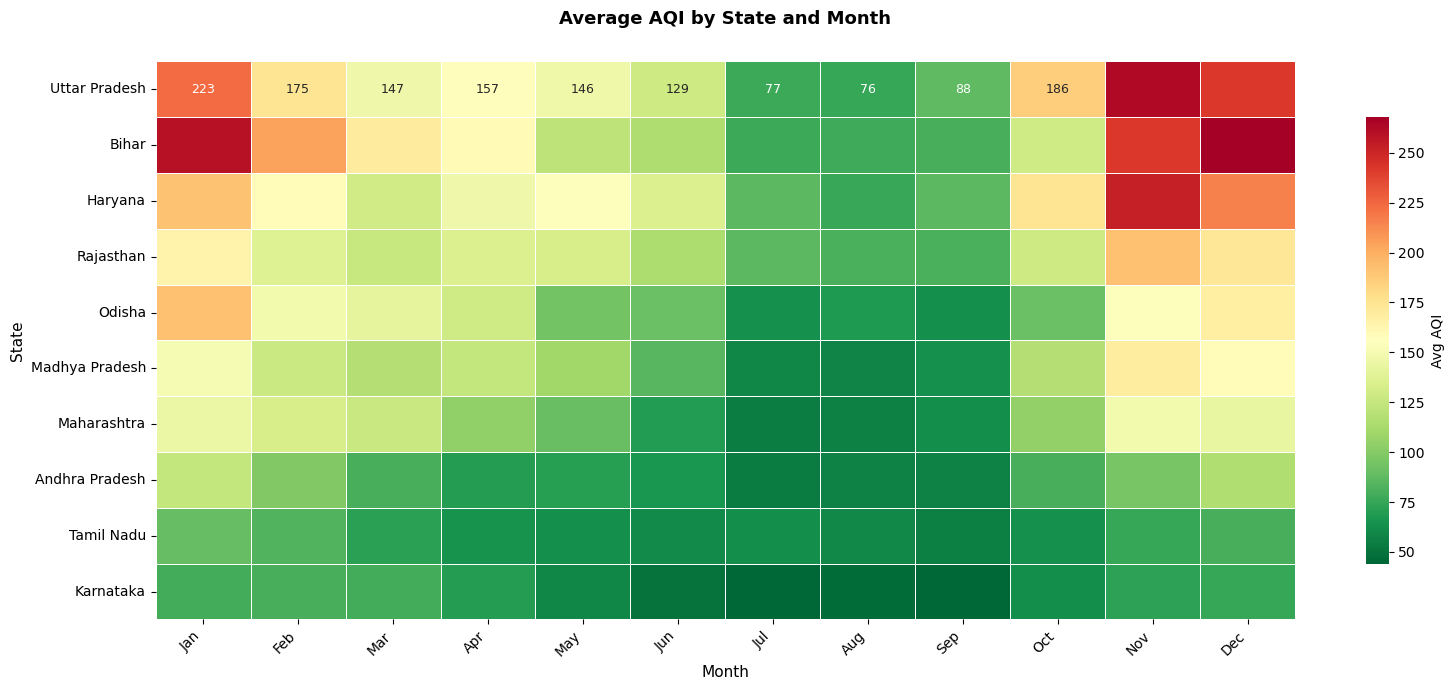

In [13]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
pivot = result.pivot_table(index='state', columns='month_name', 
                            values='avg_monthly_aqi')
pivot = pivot.reindex(columns=month_order)
pivot.columns = [m[:3] for m in pivot.columns]

# Sort states by their annual average AQI (worst to best)
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(16, 7))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Avg AQI', 'shrink': 0.8},
    annot_kws={'size': 9},
    ax=ax
)


ax.set_title('Average AQI by State and Month\n',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('State', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Key Insights & Recommendation
1. AQI is worse for the North Indian states(U.P. ,Bihar, Haryana) for most of the year, particularly during the winter season, when AQI reaches well above 200. This severe Air Quality problem supports a year-round addressable market, Even in summer, AQI stays high enough to justify purifier use. **U.P. and Bihar alone represent the largest sustained revenue opportunity.**
2. Rajasthan and Odisha show a more seasonal trend, with average AQI being above 175 for  November, December and January.
3. AQI is better for the South Indian states throughout the year, making them the low-priority zone for the product launch.

**Conclusion :** 
1. As Nov, Dec and Jan are the worst months showing consistent low AQI across all the states. September-October is the critical pre-season launch window. Marketing campaigns, retail stocking and distribution must be ready before November hits- this is when consumer purchase intent will peak nationwide.
2. July-Aug is the worst period to launch or run campaigns.Use this period for manufacturing, inventory buildup and brand awareness groundwork rather than sales push.